# Solar Adsorption-Based Atmospheric Water Harvesting (AWH) Model

## Overview
This notebook translates a validated multi-physics model for a solid desiccant Atmospheric Water Harvester (AWH) array from Engineering Equation Solver (EES) and MATLAB parameters into a completely variable Python module.

The simulation tracks an array of 27 identical modular beds over an 11-hour daytime cycle (Hours 7 to 17). It maps transient silica gel core temperatures ($T_{\text{silica}}$), loading fractions ($W$), air outlet variations, and cumulative system water vapor mass flows.

---

## 🔬 Scholarly Cross-Reference & Empirical Validation
The thermodynamic balances, desorption kinetics parameters, and physical matrix boundaries correspond to the design validated in:
*"Experimental study of a solar adsorption-based atmospheric water harvesting system for off-grid cogeneration."* **Applied Thermal Engineering**. https://doi.org/10.1016/j.applthermaleng.2025.127744

### ⚙️ Core Thermodynamic & Desorption Modeling Assumptions
1. **Uniform Bed Property (Lumped Parameter):** The desiccant silica gel core matrix is treated as a single lumped thermal capacity mass, assuming uniform temperature propagation ($\nabla T_{\text{silica}} = 0$).
2. **Ideal Antoine Saturation States:** Vapor pressures inside the stream boundaries track semi-empirical Antoine equations for pure water profiles.
3. **Isobaric Flow Conditions:** Internal duct lines and desiccant face grids operate under a uniform, unshifted atmospheric pressure stage ($P_{\text{atm}} = 101,325\text{ Pa}$).
4. **First-Order Forward Euler Discretization:** Differential mass kinetics resolve across fixed 1-second transient iterations ($\Delta t = 1\text{ s}$) to secure model stability.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Enforce clean academic plot profiles
plt.style.use('ggplot')

print("--- Cell 1: Scientific Environment and Solver Suites Deployed ---")

--- Cell 1: Scientific Environment and Solver Suites Deployed ---


# 1. Component Boundaries & Atmospheric Weather Vectors
Initializes structural matrix dimensions (silica loading limits, bed areas, transfer indices) alongside the explicit hourly solar radiation and temperature profiles from the validation paper.

In [15]:
# =============================================================================
# 1. INPUT PARAMETERS & SYSTEM DIURNAL BOUNDARIES (SI UNITS)
# =============================================================================

# System Scaling Limit
num_AWH_units = 27               # Total active modular units in the collection array

# Meteorological Profile Logs (11 points corresponding sequentially to Hours 7-17)
Tamb = np.array([14.6, 15.3, 15.9, 16.7, 18.1, 20.1, 21.1, 21.3, 20.8, 20.4, 20.1])      # Ambient Temp [°C]
Radiation = np.array([324, 408, 526, 704, 805, 825, 940, 953, 859, 654, 423])             # Solar Flux [W/m²]

# Pre-allocated Storage Arrays for Hourly Performance Tracking
T_out_hourly    = np.zeros(len(Tamb))
RH_out_hourly   = np.zeros(len(Tamb))
W_hourly        = np.zeros(len(Tamb))
T_silica_hourly = np.zeros(len(Tamb))

MFR_kg_s_hourly_total = np.zeros(len(Tamb))
MFR_kg_h_hourly_total = np.zeros(len(Tamb))

# Global Baseline State Constants
P_atm = 101325.0                 # Atmospheric pressure [Pa]

# Physical Desiccant Initial Conditions (State boundary at the START of Hour 7)
W_initial_true          = 0.27   # Initial water content loading ratio [kg_water/kg_silica]
T_silica_initial_true_C = Tamb[0]# Silica matrix temperature initialized to first hour ambient limit [°C]

# Dynamic State Registers
W_state_at_step_start          = W_initial_true
T_silica_state_at_step_start_C = T_silica_initial_true_C

print("--- Cell 2: Solar Field Environment and Array Boundaries Latched ---")

--- Cell 2: Solar Field Environment and Array Boundaries Latched ---


# 2. Coupled Micro-Macro Thermal Mass Solvers
Executes the transient evaluation loops, stepping hour-by-hour through external climate data while running secondary integrations to compute mass desorption constraints.

In [16]:
# =============================================================================
# 2. NESTED TRANSIENT MASS-BALANCING COMPUTATION ENGINE
# =============================================================================

for sim_idx in range(len(Tamb)):
    # Extract structural constraints for active simulation block
    current_Tamb_conditions_C    = Tamb[sim_idx]
    current_Radiation_conditions = Radiation[sim_idx]
    
    # Process Flow Stream Configurations (Single Harvester Unit)
    RH_in                 = 100.0       # Inlet Relative Humidity fraction [%]
    m_dot_air_single_unit = 0.4         # Dry air mass flow rate passing the bed channel [kg/s]
    time_step_inner       = 1           # Internal mathematical integration interval [s]
    total_time_inner      = 1 * 3600    # Simulation time envelope inside one solar hour [s]
    k_desorption          = 0.0001      # Mass desorption rate kinetic index [1/s]
    I_solar               = current_Radiation_conditions
    
    # Structural Physics Specifications (Per modular unit)
    Cp_air                    = 1005.0       # Specific heat of air stream [J/kg-K]
    Cp_silica                 = 850.0        # Specific heat of silica gel core [J/kg-K]
    m_silica_single_unit      = 1.4 * 10.0   # Active material mass loading per unit [kg] (14 kg)
    delta_H_desorption        = 2800.0 * 1000.0 # Latent enthalpy of desorption [J/kg]
    h_conv                    = 20.0         # Convective heat transfer coefficient [W/m²-K]
    A_bed_single_unit         = (0.3 * 0.5) * 10.0 # Effective aperture solar capture area [m²]
    W_min                     = 0.1          # Lower bound limit for material moisture matrix [kg/kg]
    Delta_T_cond_desorp_inlet = 5.0          # Temperature modification baseline approach parameter [K]

    # Map dynamic starting limits from storage registers
    T_silica_K_start_hour     = T_silica_state_at_step_start_C + 273.15
    W_silica_start_hour       = W_state_at_step_start
    T_in_desorp_C             = current_Tamb_conditions_C + Delta_T_cond_desorp_inlet

    time_array_inner = np.arange(0, total_time_inner + time_step_inner, time_step_inner)
    
    T_silica_current_K = T_silica_K_start_hour
    W_silica_current   = W_silica_start_hour

    # --- Second-by-Second Inner Forward Euler Integration Loop ---
    for _ in range(len(time_array_inner)):
        Q_solar_J_per_step = I_solar * A_bed_single_unit * time_step_inner * (1.0 - 0.2) * 0.6
        W_eq_silica = W_min + (W_silica_start_hour - W_min) * np.exp(-0.01 * (T_silica_current_K - 273.15))
        
        dW_dt_silica = -k_desorption * (W_silica_current - W_eq_silica)
        delta_W_silica = dW_dt_silica * time_step_inner
        W_silica_current = max(W_silica_current + delta_W_silica, W_min)
        
        m_water_desorbed_step_kg_single_unit = abs(delta_W_silica) * m_silica_single_unit
        Q_desorption_J_per_step = m_water_desorbed_step_kg_single_unit * delta_H_desorption
        Q_transfer_J_per_step = h_conv * A_bed_single_unit * (T_silica_current_K - (T_in_desorp_C + 273.15)) * time_step_inner
        
        dT_silica_K = (Q_solar_J_per_step - Q_transfer_J_per_step - Q_desorption_J_per_step) / (m_silica_single_unit * Cp_silica)
        T_silica_current_K += dT_silica_K
        
        T_out_AWH_current_K = (T_in_desorp_C + 273.15) + (Q_transfer_J_per_step / (m_dot_air_single_unit * Cp_air * time_step_inner))
        T_out_AWH_current_C_val = T_out_AWH_current_K - 273.15
        
        # Psychrometric state extraction via Antoine Vapor Pressure
        P_sat_in_desorp_mmHg = 10**(8.07131 - 1730.63 / (233.426 + T_in_desorp_C))
        P_vapor_in_desorp_Pa = (RH_in / 100.0) * P_sat_in_desorp_mmHg * 133.322
        w_in_desorp = 0.622 * P_vapor_in_desorp_Pa / (P_atm - P_vapor_in_desorp_Pa)
        
        w_out_AWH = w_in_desorp + (m_water_desorbed_step_kg_single_unit / time_step_inner) / m_dot_air_single_unit
        
        P_sat_out_AWH_mmHg = 10**(8.07131 - 1730.63 / (233.426 + T_out_AWH_current_C_val))
        P_sat_out_AWH_Pa = P_sat_out_AWH_mmHg * 133.322
        P_vapor_out_AWH_Pa = (w_out_AWH * P_atm) / (0.622 + w_out_AWH)
        
        RH_out_AWH_current_val = min((P_vapor_out_AWH_Pa / P_sat_out_AWH_Pa) * 100.0, 100.0)
        if P_sat_out_AWH_Pa <= 0:
            RH_out_AWH_current_val = 100.0

    # Save finalized hourly values
    T_out_hourly[sim_idx]    = T_out_AWH_current_C_val
    RH_out_hourly[sim_idx]   = RH_out_AWH_current_val
    W_hourly[sim_idx]        = W_silica_current
    T_silica_hourly[sim_idx] = T_silica_current_K - 273.15
    
    # Resolve total combined fluid production rates from the 27 units
    water_produced_AWH_this_hour_kg_single_unit = (W_silica_start_hour - W_hourly[sim_idx]) * m_silica_single_unit
    MFR_kg_s_hourly_total[sim_idx] = (water_produced_AWH_this_hour_kg_single_unit / total_time_inner) * num_AWH_units
    MFR_kg_h_hourly_total[sim_idx] = water_produced_AWH_this_hour_kg_single_unit * num_AWH_units
    
    # Cascade states to registers for the subsequent period boundary
    W_state_at_step_start          = W_hourly[sim_idx]
    T_silica_state_at_step_start_C = T_silica_hourly[sim_idx]

print("--- Cell 3: Coupled Thermal Mass Transient Solver Converged ---")

--- Cell 3: Coupled Thermal Mass Transient Solver Converged ---


# 3. Academic Plot Rendering & Automated Core Metrics Summary
Generates the comprehensive 5-panel performance charts tracking airstream variations and desorption progress alongside an automated validation summary log.

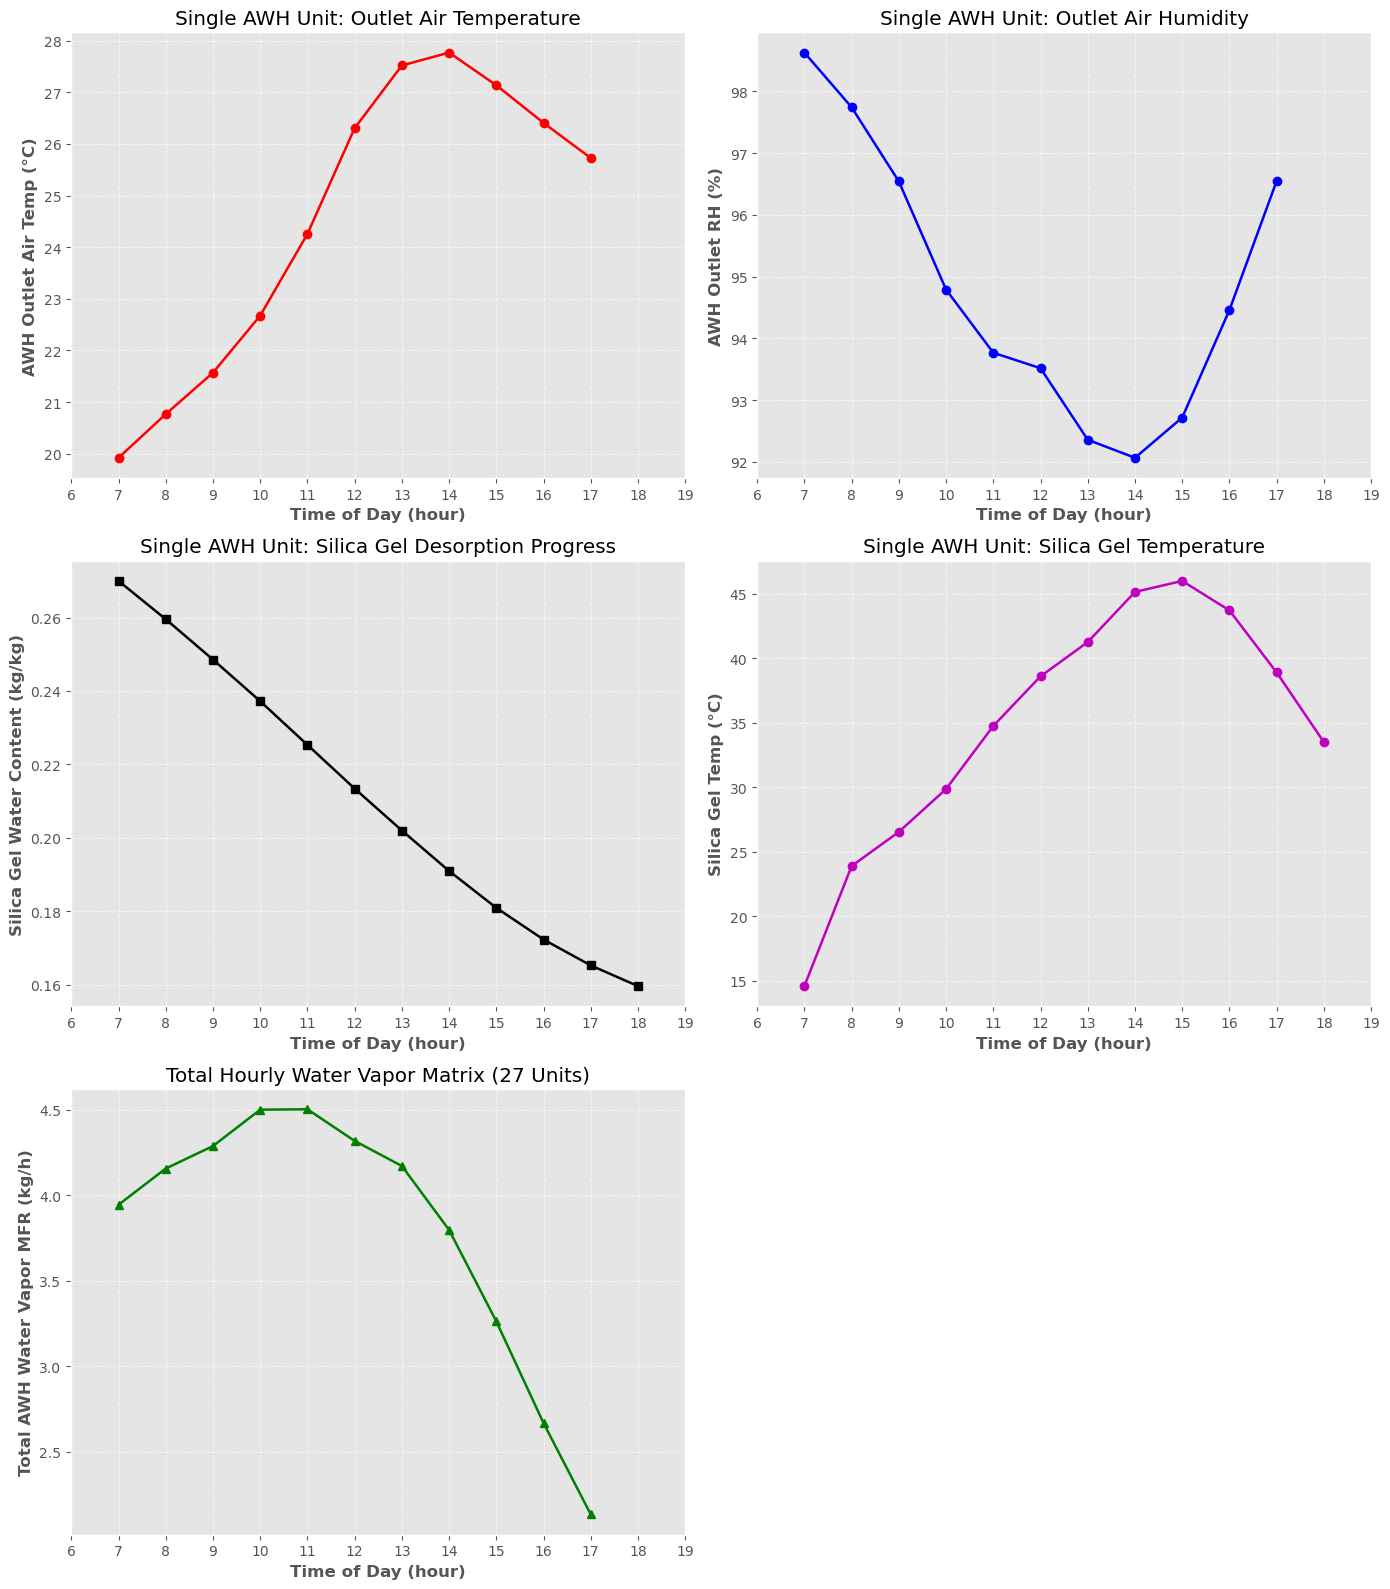

     AWH FIELD CONVERGENCE PERFORMANCE SUMMARY    
Active Simulated AWH Core Units: 27 Unit(s)
Integrated System Desiccant Bed: 378.00 kg
--------------------------------------------------
 Hour 07:00 Base Yield : 3.9450 kg/h (1.10e-03 kg/s)
 Hour 08:00 Base Yield : 4.1569 kg/h (1.15e-03 kg/s)
 Hour 09:00 Base Yield : 4.2885 kg/h (1.19e-03 kg/s)
 Hour 10:00 Base Yield : 4.5012 kg/h (1.25e-03 kg/s)
 Hour 11:00 Base Yield : 4.5036 kg/h (1.25e-03 kg/s)
 Hour 12:00 Base Yield : 4.3185 kg/h (1.20e-03 kg/s)
 Hour 13:00 Base Yield : 4.1719 kg/h (1.16e-03 kg/s)
 Hour 14:00 Base Yield : 3.7975 kg/h (1.05e-03 kg/s)
 Hour 15:00 Base Yield : 3.2628 kg/h (9.06e-04 kg/s)
 Hour 16:00 Base Yield : 2.6678 kg/h (7.41e-04 kg/s)
 Hour 17:00 Base Yield : 2.1337 kg/h (5.93e-04 kg/s)
--------------------------------------------------
Absolute Daily Matrix Mass Yield: 41.747 kg/day
Specific Moisture Production    : 11.04 %


In [17]:
# =============================================================================
# 3. GRAPHICS VISUALIZER & PERFORMANCE PORTFOLIO REPORTER
# =============================================================================

# Compute overall system total yields
Total_water_AWH_kg_single_unit = (W_initial_true - W_hourly[-1]) * m_silica_single_unit
SMP_per_unit                   = 100.0 * Total_water_AWH_kg_single_unit / m_silica_single_unit
Total_water_AWH_kg_all_units   = Total_water_AWH_kg_single_unit * num_AWH_units

# Generate daytime time axis arrays matching diurnal bounds (Hours 7-17)
plot_time_axis            = np.arange(1, len(Tamb) + 1) + 6
plot_time_W_states        = np.arange(0, len(Tamb) + 1) + 7
plot_time_T_silica_states = np.arange(0, len(Tamb) + 1) + 7

# Initialize dual-column subplots matrix
fig, axs = plt.subplots(3, 2, figsize=(14, 16))
fig.delaxes(axs[2, 1])  # Clear empty spacer frame

# [1] Outlet Air Temperature Evolution
axs[0, 0].plot(plot_time_axis, T_out_hourly, 'r-o', linewidth=1.8)
axs[0, 0].set_xlabel('Time of Day (hour)', fontweight='bold')
axs[0, 0].set_ylabel('AWH Outlet Air Temp (°C)', fontweight='bold')
axs[0, 0].set_title('Single AWH Unit: Outlet Air Temperature')
axs[0, 0].set_xlim([6, 19]); axs[0, 0].set_xticks(range(6, 20))
axs[0, 0].grid(True, linestyle='--', alpha=0.6)

# [2] Outlet Relative Humidity Evolution
axs[0, 1].plot(plot_time_axis, RH_out_hourly, 'b-o', linewidth=1.8)
axs[0, 1].set_xlabel('Time of Day (hour)', fontweight='bold')
axs[0, 1].set_ylabel('AWH Outlet RH (%)', fontweight='bold')
axs[0, 1].set_title('Single AWH Unit: Outlet Air Humidity')
axs[0, 1].set_xlim([6, 19]); axs[0, 1].set_xticks(range(6, 20))
axs[0, 1].grid(True, linestyle='--', alpha=0.6)

# [3] Silica Gel Adsequent Loading Desorption Curve
plot_W_values = np.insert(W_hourly, 0, W_initial_true)
axs[1, 0].plot(plot_time_W_states, plot_W_values, 'k-s', linewidth=1.8)
axs[1, 0].set_xlabel('Time of Day (hour)', fontweight='bold')
axs[1, 0].set_ylabel('Silica Gel Water Content (kg/kg)', fontweight='bold')
axs[1, 0].set_title('Single AWH Unit: Silica Gel Desorption Progress')
axs[1, 0].set_xlim([6, 19]); axs[1, 0].set_xticks(range(6, 20))
axs[1, 0].grid(True, linestyle='--', alpha=0.6)

# [4] Silica Gel Thermal Vector Response
plot_T_silica_values = np.insert(T_silica_hourly, 0, T_silica_initial_true_C)
axs[1, 1].plot(plot_time_T_silica_states, plot_T_silica_values, 'm-o', linewidth=1.8)
axs[1, 1].set_xlabel('Time of Day (hour)', fontweight='bold')
axs[1, 1].set_ylabel('Silica Gel Temp (°C)', fontweight='bold')
axs[1, 1].set_title('Single AWH Unit: Silica Gel Temperature')
axs[1, 1].set_xlim([6, 19]); axs[1, 1].set_xticks(range(6, 20))
axs[1, 1].grid(True, linestyle='--', alpha=0.6)

# [5] Total Fluid Yield Flow Capacity (All Units Combined)
axs[2, 0].plot(plot_time_axis, MFR_kg_h_hourly_total, 'g-^', linewidth=1.8)
axs[2, 0].set_xlabel('Time of Day (hour)', fontweight='bold')
axs[2, 0].set_ylabel('Total AWH Water Vapor MFR (kg/h)', fontweight='bold')
axs[2, 0].set_title(f'Total Hourly Water Vapor Matrix ({num_AWH_units} Units)')
axs[2, 0].set_xlim([6, 19]); axs[2, 0].set_xticks(range(6, 20))
axs[2, 0].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# =============================================================================
# 6. COMPREHENSIVE REPRODUCIBILITY KEY RESULTS REPORT
# =============================================================================
print(f"==================================================")
print(f"     AWH FIELD CONVERGENCE PERFORMANCE SUMMARY    ")
print(f"==================================================")
print(f"Active Simulated AWH Core Units: {num_AWH_units} Unit(s)")
print(f"Integrated System Desiccant Bed: {m_silica_single_unit * num_AWH_units:.2f} kg")
print(f"--------------------------------------------------")
for print_idx in range(len(Tamb)):
    actual_hour = print_idx + 7
    print(f" Hour {actual_hour:02d}:00 Base Yield : {MFR_kg_h_hourly_total[print_idx]:.4f} kg/h ({MFR_kg_s_hourly_total[print_idx]:.2e} kg/s)")
print(f"--------------------------------------------------")
print(f"Absolute Daily Matrix Mass Yield: {Total_water_AWH_kg_all_units:.3f} kg/day")
print(f"Specific Moisture Production    : {SMP_per_unit:.2f} %")
print(f"==================================================")